In [1]:
# Python 3.10.11
%pip install -r requirements.txt > /dev/null

from args import *

Note: you may need to restart the kernel to use updated packages.


In [2]:
import scanpy as sc
import omicverse as ov
import matplotlib.pyplot as plt
ov.plot_set()


   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

Version: 1.6.8, Tutorials: https://omicverse.readthedocs.io/
Dependency error: The 'scrublet>=0.2' distribution was not found and is required by the application


In [3]:
#import PyWGCNA
pyWGCNA_5xFAD=ov.bulk.readWGCNA(data_output_dir_path / '5xFAD_2k.p')

Reading 5xFAD_2k WGCNA done!


In [4]:
pyWGCNA_5xFAD.mol.head()

,ivl,module,name,dynamo_color,module_color
0,4249,3,EXPH5,darkgrey,darkgrey
1,4250,2,SLC26A5,red,red
2,3857,2,ZNF175,red,red
3,8168,3,ZNF594,darkgrey,darkgrey
4,3929,8,LOC100101266,paleturquoise,paleturquoise


In [5]:
# 只保留 module 和 module_color 列
import pandas as pd

module_info_df = pyWGCNA_5xFAD.mol[['module', 'module_color']].drop_duplicates()
module_info_df = pd.merge(module_info_df, pyWGCNA_5xFAD.mol['module'].value_counts(), on='module', how='left')
module_info_df = module_info_df.sort_values(by="module")

In [6]:
module_info_df.head()

,module,module_color,count
5,0,black,17
6,1,red,1826
1,2,red,1307
0,3,darkgrey,1165
14,4,gold,1149


In [7]:
# 测试代码，筛选出指定子模块进行分析
threshold = 100_000

filter_module_list = module_info_df[module_info_df['count'] < threshold].to_dict(orient='records')

In [8]:
filter_module_id_list = [module['module'] for module in filter_module_list ]
filter_module_name_list = [module['module_color'] for module in filter_module_list ]

In [9]:
pyWGCNA_5xFAD.datExpr.var.head()

,dynamicColors,moduleColors,moduleLabels
sample,,,
ZNF660,red,red,20
SULT1C4,paleturquoise,paleturquoise,19
ITGA9,paleturquoise,paleturquoise,19
THSD7A,paleturquoise,paleturquoise,19
SNED1,red,red,20


In [10]:
filtered_gene_df = pyWGCNA_5xFAD.datExpr.var[pyWGCNA_5xFAD.datExpr.var["moduleLabels"].isin(filter_module_id_list)]

In [11]:
filtered_gene_df.head()

,dynamicColors,moduleColors,moduleLabels
sample,,,
ZNF660,red,red,20
SULT1C4,paleturquoise,paleturquoise,19
ITGA9,paleturquoise,paleturquoise,19
THSD7A,paleturquoise,paleturquoise,19
SNED1,red,red,20


In [12]:
filtered_color_list = filtered_gene_df["moduleColors"].values[:]
filtered_color_list = list(set(filtered_color_list))

In [13]:
g_sub_edages_dict = {}
for mod in filtered_color_list:
    G_sub=pyWGCNA_5xFAD.get_sub_network(mod_list=[mod],
                                mod_type='module_color',correlation_threshold=0.2)
    if mod not in g_sub_edages_dict:
        g_sub_edages_dict[mod] = len(G_sub.edges())

In [14]:
"""
lemonchiffon: 1
red: 364
paleturquoise: 7
darkorchid: 16
saddlebrown: 5
yellowgreen: 43318
hotpink: 5
darkolivegreen: 1
"""
filtered_color_list = []
for color, edages in g_sub_edages_dict.items():
    if edages == 0:
        continue
    print(f"{color}: {edages}")
    filtered_color_list.append(color)

yellowgreen: 43318
darkorchid: 16
saddlebrown: 5
hotpink: 5
red: 364
darkolivegreen: 1
paleturquoise: 7
lemonchiffon: 1


In [15]:
sub_mol=pyWGCNA_5xFAD.get_sub_module(filtered_color_list, mod_type='module_color')
sub_mol.head(),sub_mol.shape

(    ivl  module          name   dynamo_color   module_color
 1  4250       2       SLC26A5            red            red
 2  3857       2        ZNF175            red            red
 4  3929       8  LOC100101266  paleturquoise  paleturquoise
 5  3880       8        ZNF491  paleturquoise  paleturquoise
 6  3930       8        ZNF625  paleturquoise  paleturquoise,
 (7323, 5))

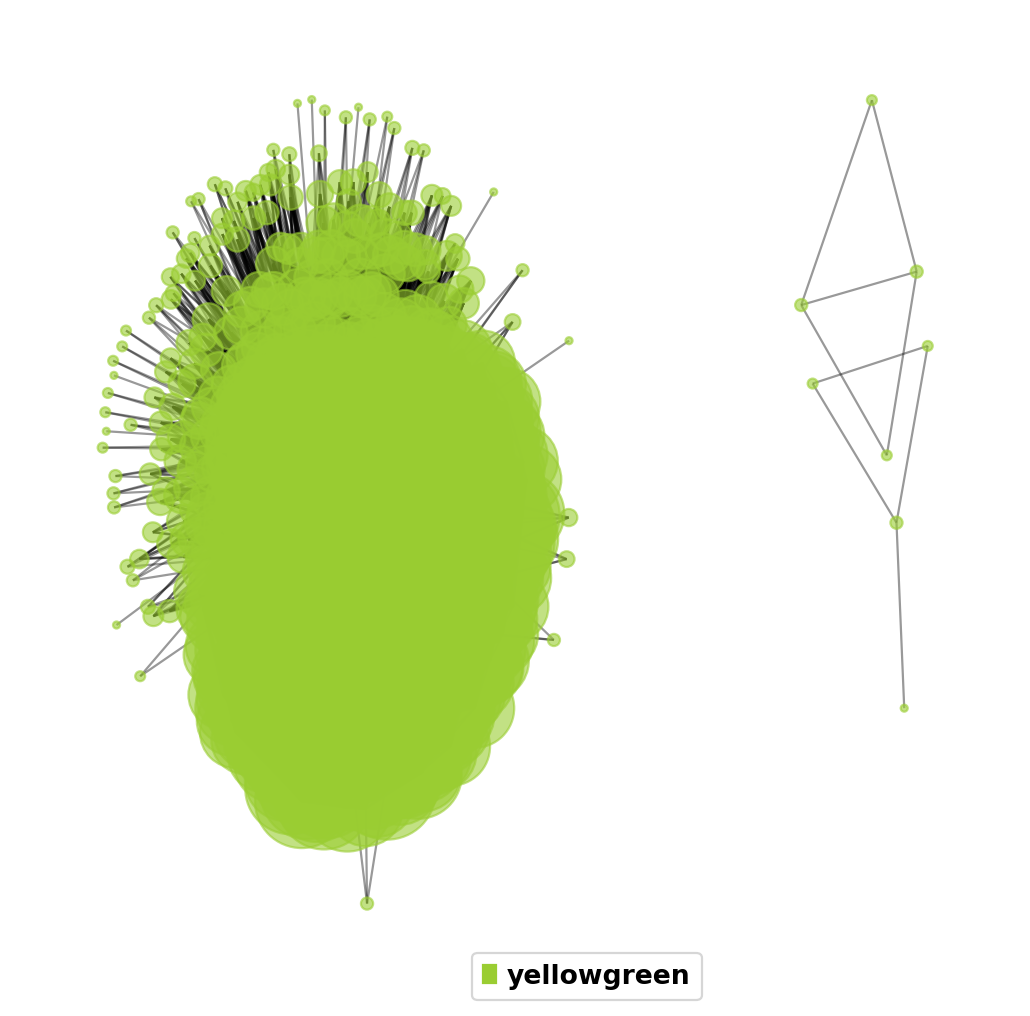

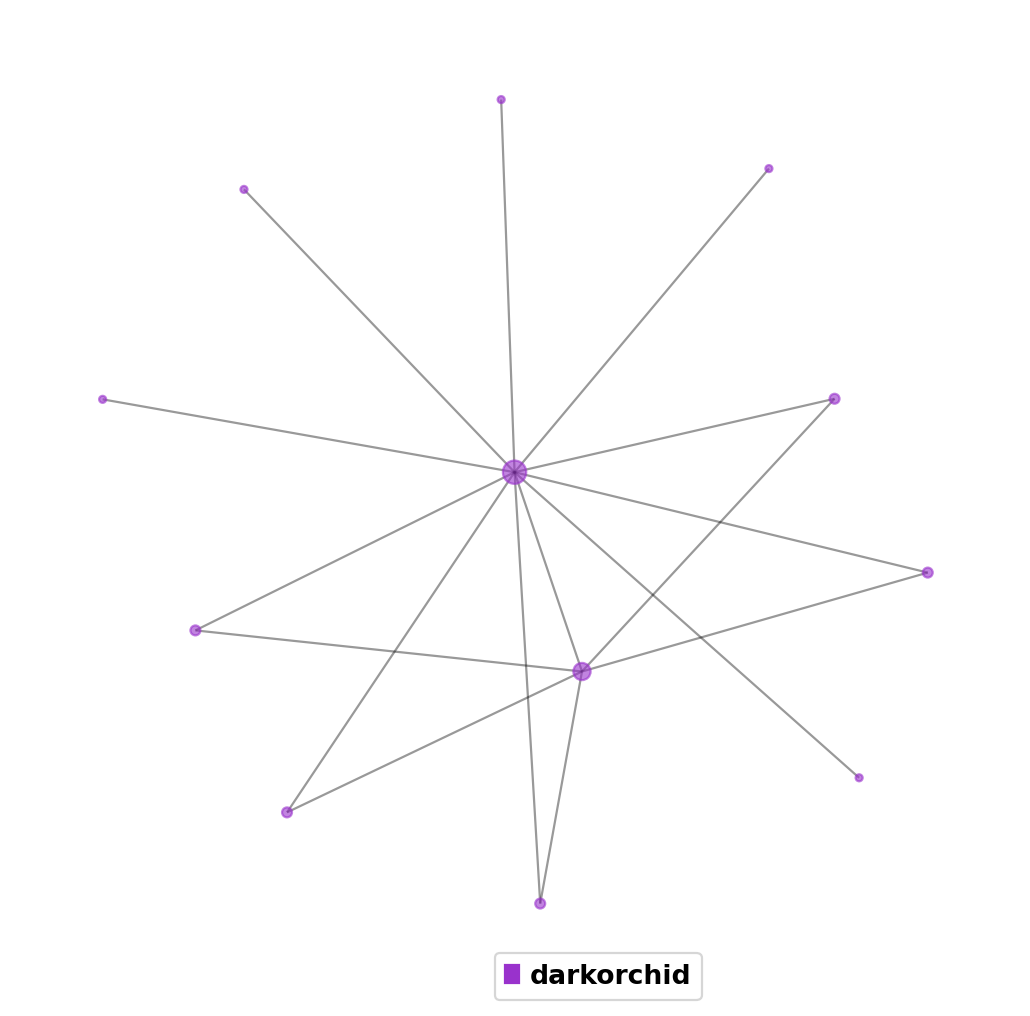

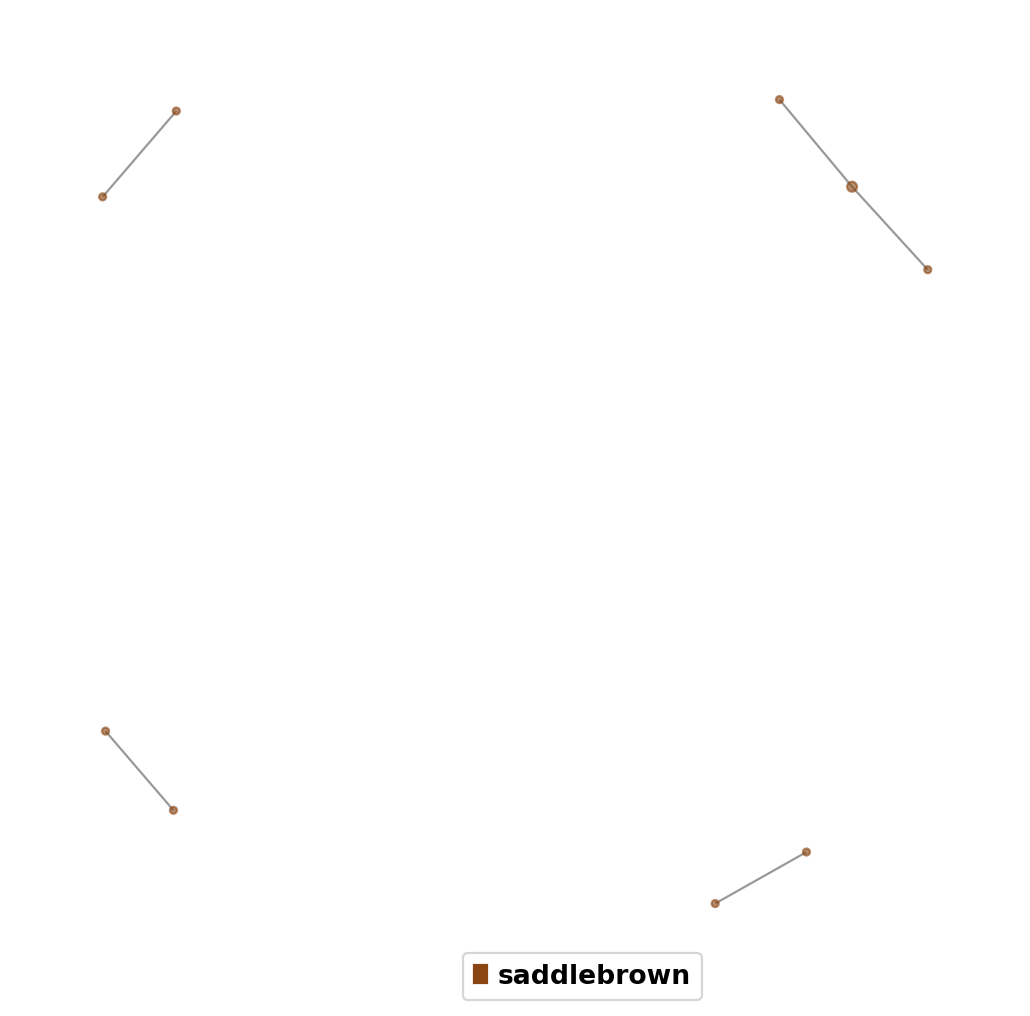

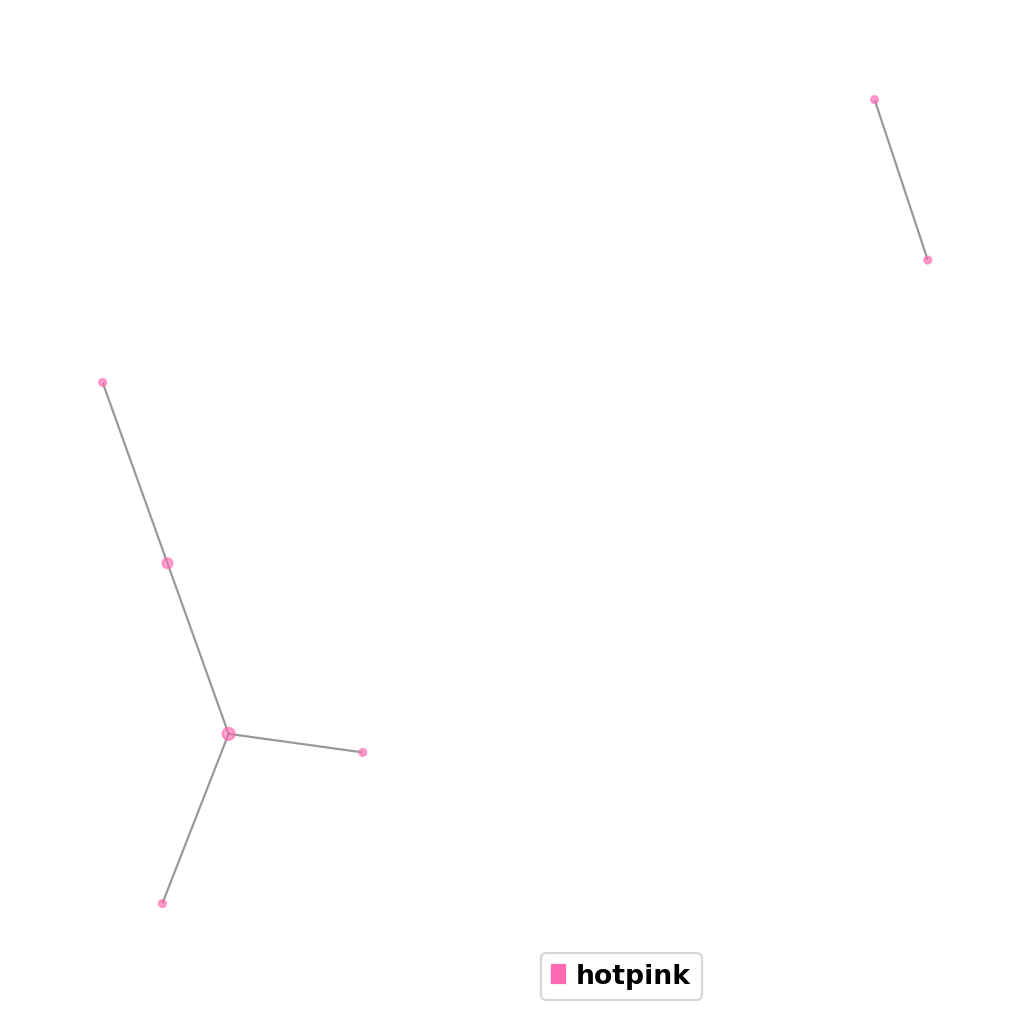

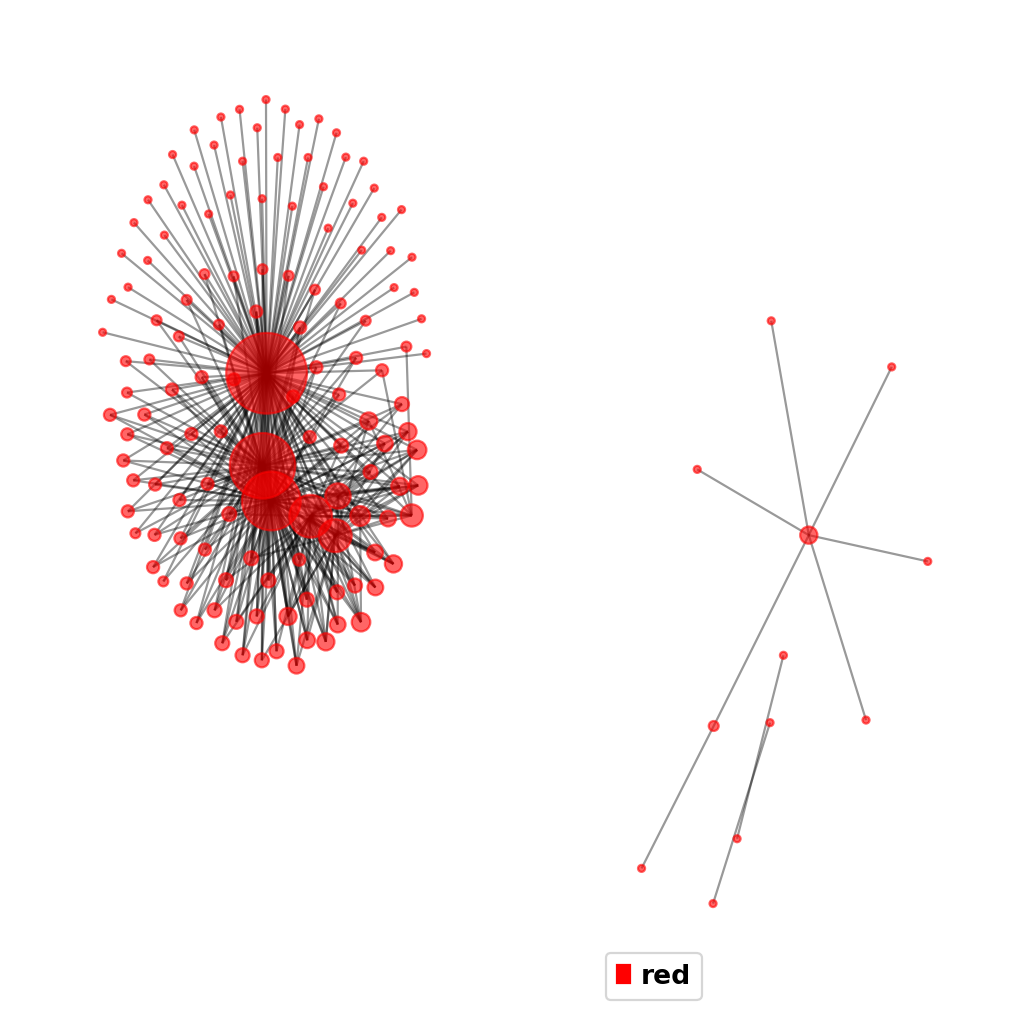

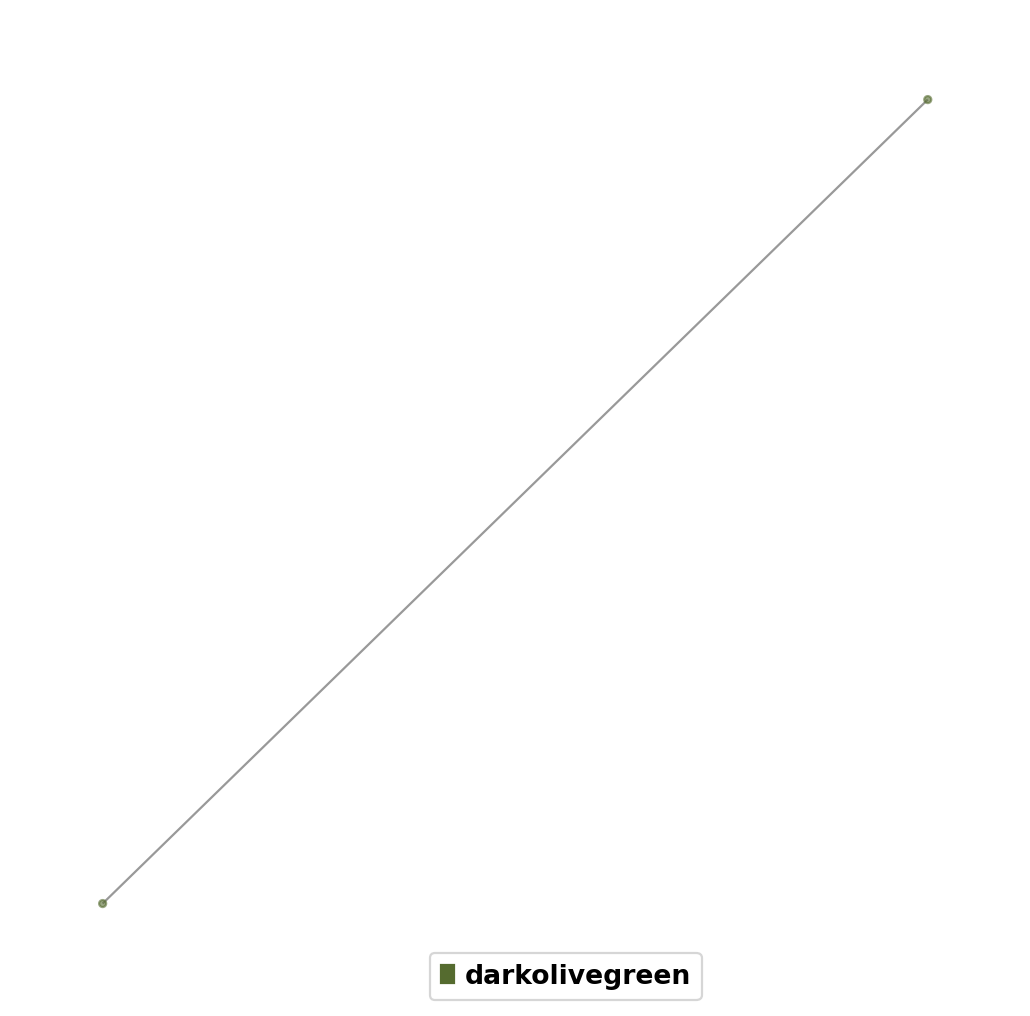

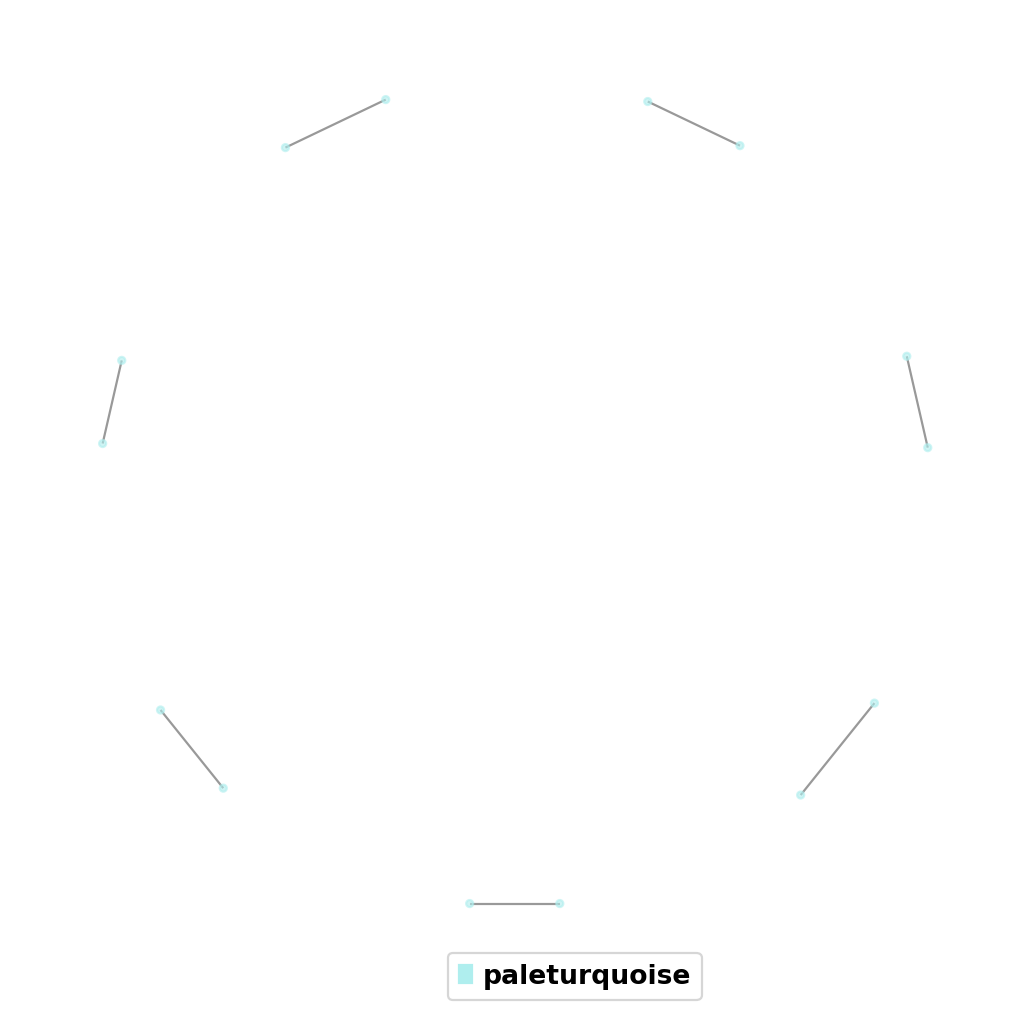

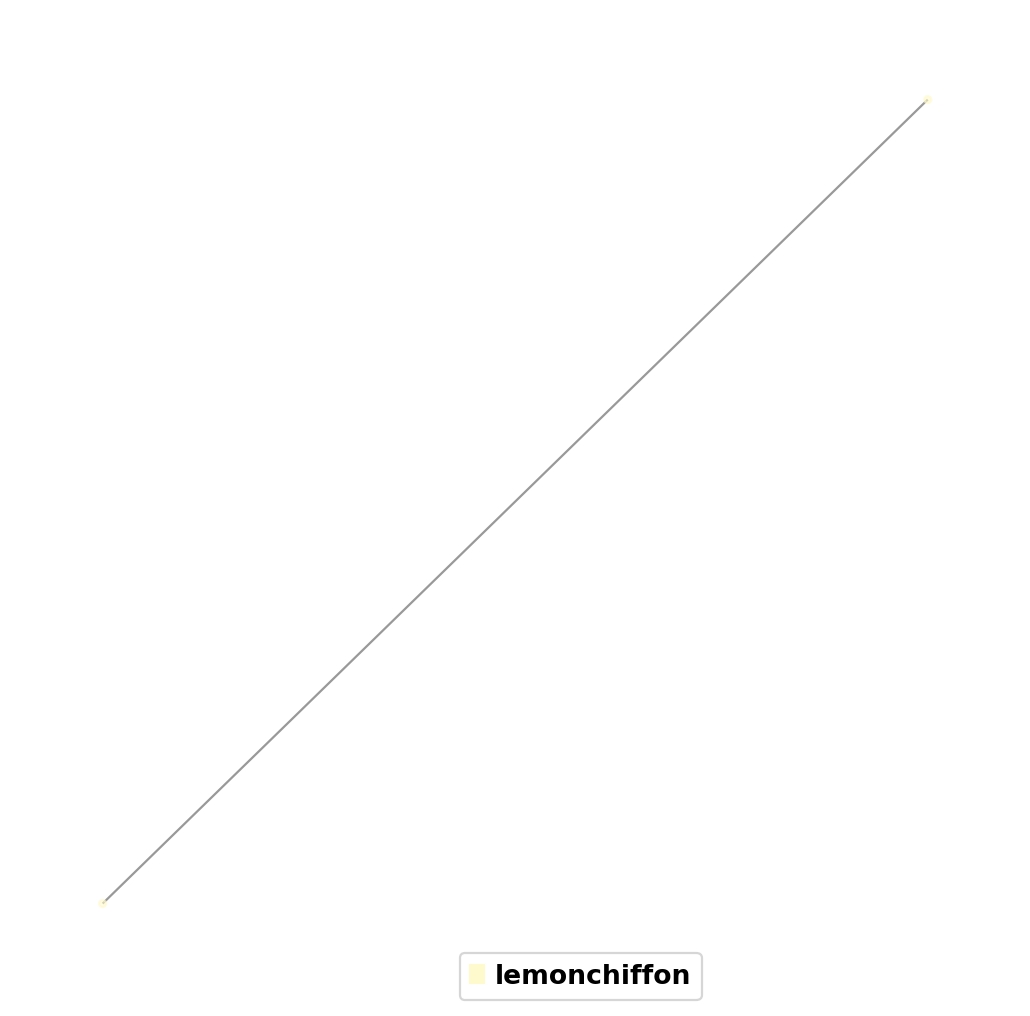

In [16]:
for mod in filtered_color_list:
    pyWGCNA_5xFAD.plot_sub_network([mod], pos_type='kamada_kawai',pos_scale=10,pos_dim=2,
                            figsize=(8,8),node_size=10,label_fontsize=8,correlation_threshold=0.2,
                            label_bbox={"ec": "white", "fc": "white", "alpha": 0.6})

In [17]:
metadata = pyWGCNA_5xFAD.datExpr.obs.columns.tolist()

In [18]:
for mod in filtered_color_list:
    pyWGCNA_5xFAD.plotModuleEigenGene(mod, metadata, show=False)

In [21]:
save_dir = data_output_dir_path / "connect_top"
if not save_dir.exists():
    save_dir.mkdir()
for mod in filtered_color_list:
    connect_top_df = pyWGCNA_5xFAD.top_n_hub_genes(moduleName=mod, n=1_000_000)

    connect_mean = connect_top_df["connectivity"].mean()
    print("Module: ", mod, "Mean: ", connect_mean)
    connect_top_df[connect_top_df["connectivity"] > connect_mean].to_csv(save_dir / f"{mod}_connect_top.csv")

calculating adjacency matrix ...
	Done..

Module:  yellowgreen Mean:  40.704344653808775
calculating adjacency matrix ...
	Done..

Module:  darkorchid Mean:  13.18079656882868
calculating adjacency matrix ...
	Done..

Module:  saddlebrown Mean:  6.858955217163508
calculating adjacency matrix ...


	Done..

Module:  hotpink Mean:  12.47126046103345
calculating adjacency matrix ...
	Done..

Module:  red Mean:  15.354443076812332
calculating adjacency matrix ...
	Done..

Module:  darkolivegreen Mean:  5.847308993263491
calculating adjacency matrix ...
	Done..

Module:  paleturquoise Mean:  5.504326097962916
calculating adjacency matrix ...
	Done..

Module:  lemonchiffon Mean:  3.103682466831748
